<a href="https://colab.research.google.com/github/JeriesKawaneh/Prediction-of-Product-Sales/blob/main/Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Description: Income Level Prediction

This project focuses on building and evaluating machine learning models to predict an individual's income level based on various demographic and socioeconomic features. The dataset used contains information such as age, education, marital status, occupation, and capital gains/losses.

### Project Goals:

1.  **Data Preprocessing and Cleaning:** To thoroughly clean and preprocess the raw data, including handling missing values, encoding categorical features, and scaling numerical features, to prepare it for machine learning models.
2.  **Exploratory Data Analysis (EDA):** To understand the distribution of features, identify potential relationships, and gain insights into factors influencing income.
3.  **Model Development and Evaluation (Random Forest):** To develop a Random Forest Classifier for income prediction, evaluate its performance, and address common machine learning challenges like overfitting.
4.  **Feature Importance Analysis:** To identify and visualize the most influential features that contribute to income prediction using permutation importance.
5.  **Addressing Class Imbalance:** To apply techniques like SMOTE (Synthetic Minority Over-sampling Technique) to handle class imbalance in the target variable.
6.  **Dimensionality Reduction:** To explore the impact of Principal Component Analysis (PCA) on model performance.
7.  **Neural Network Implementation:** To build and train simple neural network models using Keras for comparison with tree-based models.

### Project Outcomes:

*   **Cleaned and Preprocessed Dataset:** A robust pipeline for data cleaning, imputation, encoding, and scaling was established.
*   **Identified Key Predictors:** Features such as `capital-gain`, `marital-status`, `relationship`, `educational-num`, and `occupation` were identified as highly important for income prediction.
*   **Comparative Model Performance:** Multiple models (Random Forest, Keras Neural Networks) were trained and evaluated, revealing insights into their respective strengths and weaknesses, particularly regarding overfitting.
*   **Demonstrated Techniques for Overfitting and Imbalance:** The project demonstrated the application of SMOTE for balancing classes and the challenges of overfitting, providing a foundation for future model improvements and hyperparameter tuning.
*   **Visualizations:** Key data distributions and feature importances were visualized to aid in understanding and communication of findings.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from tensorflow.keras import Sequential
from tensorflow.keras import metrics
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [ ]:
#importing the useful metrics functions

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filename = '/content/drive/MyDrive/adult.csv'
df = pd.read_csv(filename)
# Inspect data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
#check the type
df['income'].dtypes

dtype('O')

In [ ]:
for col in df.columns:
  print(f"Column: {col}")
  print(df[col].value_counts())
  print("-" * 40)

Column: age
age
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64
----------------------------------------
Column: workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
----------------------------------------
Column: fnlwgt
fnlwgt
203488    21
190290    19
120277    19
125892    18
126569    18
          ..
436163     1
320084     1
125976     1
211349     1
120478     1
Name: count, Length: 28523, dtype: int64
----------------------------------------
Column: education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-

In [ ]:
df['workclass'] = df['workclass'].replace('?', np.nan)
df['occupation'] = df['occupation'].replace('?', np.nan)
df['native-country'] = df['native-country'].replace('?', np.nan)

In [ ]:
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [ ]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.duplicated().sum()

np.int64(52)

In [ ]:
duplicated_all=df.duplicated(keep=False)
df_duplicated=df[duplicated_all]
df_duplicated

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
488,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
864,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
1319,37,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
1668,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
1854,22,Private,137876,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,20,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46665,20,NaN,203353,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,40,United-States,<=50K
46979,22,NaN,334593,Some-college,10,Never-married,NaN,Not-in-family,White,Male,0,0,40,United-States,<=50K
47126,46,Private,133616,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48274,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K


In [ ]:
df=df.drop_duplicates(keep='first')

In [ ]:
duplicated=df.duplicated().sum()
duplicated

np.int64(0)

In [ ]:
df.isna().sum()

,0
age,0
workclass,2795
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
X = df.drop('income', axis=1)
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
#numeric columns
num_cols= ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
ord_cols = ['education']
nom_cols = ['workclass', 'marital-status', 'occupation', 'relationship','gender','race', 'native-country']

In [ ]:
num_imputer = SimpleImputer(strategy='median')
num_scaler = StandardScaler()
num_pipe = make_pipeline(num_imputer, num_scaler)
num_tuple = ('Numeric',num_pipe, num_cols)
print (num_tuple)

('Numeric', Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())]), ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week'])


In [ ]:
nom_imputer = SimpleImputer(strategy='constant', fill_value='missing')
nom_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
nom_pipe = make_pipeline(nom_imputer, nom_encoder)
nom_tuple = ('Nominal',nom_pipe, nom_cols)
print (nom_tuple)

('Nominal', Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), ['workclass', 'marital-status', 'occupation', 'relationship', 'gender', 'race', 'native-country'])


In [ ]:
ord_imputer = SimpleImputer(strategy='constant', fill_value='missing')
ord_encoder = OrdinalEncoder()
ord_scaler = StandardScaler()
ord_pipe = make_pipeline(ord_imputer, ord_encoder,ord_scaler)
ord_tuple = ('Ordinal',ord_pipe, ord_cols)
print (ord_tuple)

('Ordinal', Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('ordinalencoder', OrdinalEncoder()),
                ('standardscaler', StandardScaler())]), ['education'])


In [ ]:
preprocessor = ColumnTransformer([num_tuple, nom_tuple,ord_tuple], verbose_feature_names_out=False)

In [ ]:
X = df.drop('income', axis=1)
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
rf = RandomForestClassifier(random_state=42)

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'educational-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('Nominal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 str...
                                                   'occupation', 'relationship',
                                                   'gender', 'race',
                                                   'native-country']),
                                                 ('Ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['education'])],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

Randomforest Default Accuracy: 0.8582554517133957
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27841
        >50K       1.00      1.00      1.00      8751

    accuracy                           1.00     36592
   macro avg       1.00      1.00      1.00     36592
weighted avg       1.00      1.00      1.00     36592



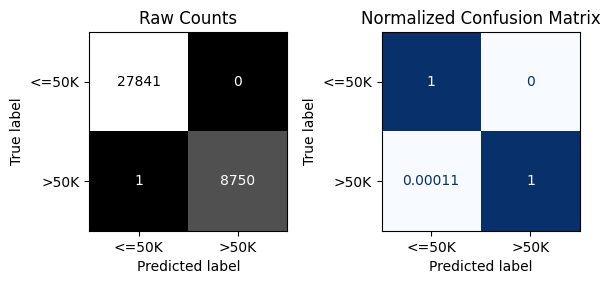


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      9268
        >50K       0.75      0.62      0.68      2930

    accuracy                           0.86     12198
   macro avg       0.82      0.78      0.79     12198
weighted avg       0.85      0.86      0.85     12198



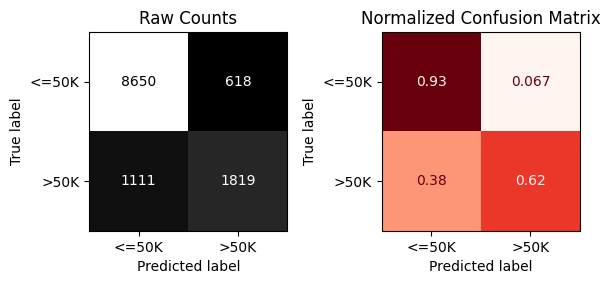

In [ ]:
from sklearn.metrics import accuracy_score
y_pred_rf = rf_pipe.predict(X_test)
print("Randomforest Default Accuracy:", accuracy_score(y_test, y_pred_rf))
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

## This model is not reliable for it is overfitting clearly.

In [ ]:
from sklearn.inspection import permutation_importance
result= permutation_importance(rf_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='f1_macro')

In [ ]:
feature_importances = pd.Series(result.importances_mean, index=X_test.columns)

In [ ]:
#visualize top 10 features
top_10_features = feature_importances.sort_values(ascending=False).head(10)
top_10_features

,0
capital-gain,0.056216
marital-status,0.056177
relationship,0.046375
educational-num,0.037094
occupation,0.035038
age,0.033780
capital-loss,0.016253
hours-per-week,0.014663
workclass,0.006998
gender,0.004579


* Yes, these features generally make strong business sense. High importance of marital-status, educational-num, and capital-gain aligns with economic factors like household income, qualifications, and wealth. Capital-loss and hours-per-week also logically relate to financial activity and work effort. Features with zero importance (fnlwgt, education, workclass, occupation) are either redundant or not directly utilized by this specific Decision Tree model.

/tmp/ipykernel_5985/2883614626.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')


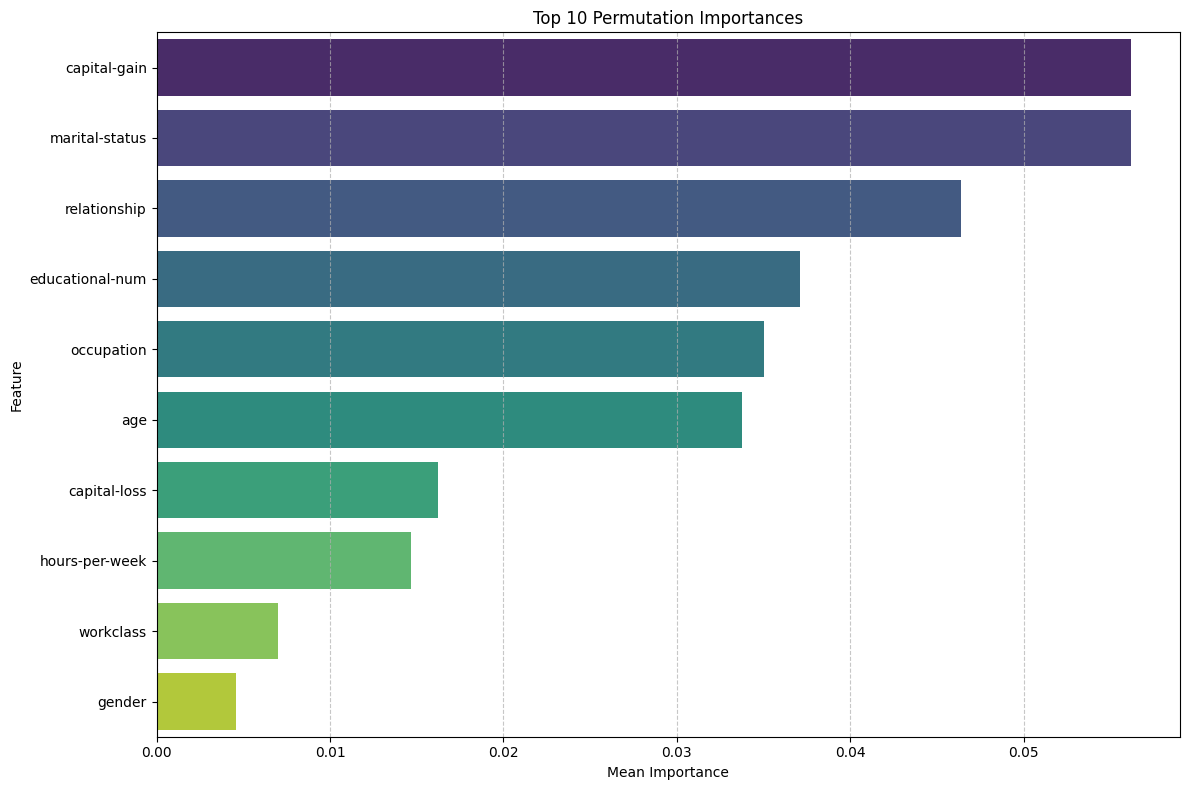

Permutation importance calculated and top 10 features visualized.


In [ ]:
#Top 10 Permutation importance
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
plt.title('Top 10 Permutation Importances')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Permutation importance calculated and top 10 features visualized.")

### Explanation of Top 10 Permutation Importances

This visualization highlights features most crucial for our Random Forest model's income predictions. Features like capital-gain, marital-status, and relationship are highly impactful, indicating strong predictive power related to wealth, household situation, and family structure. Educational-num, occupation, and age also contribute significantly, while capital-loss, hours-per-week, workclass, and gender show moderate importance.

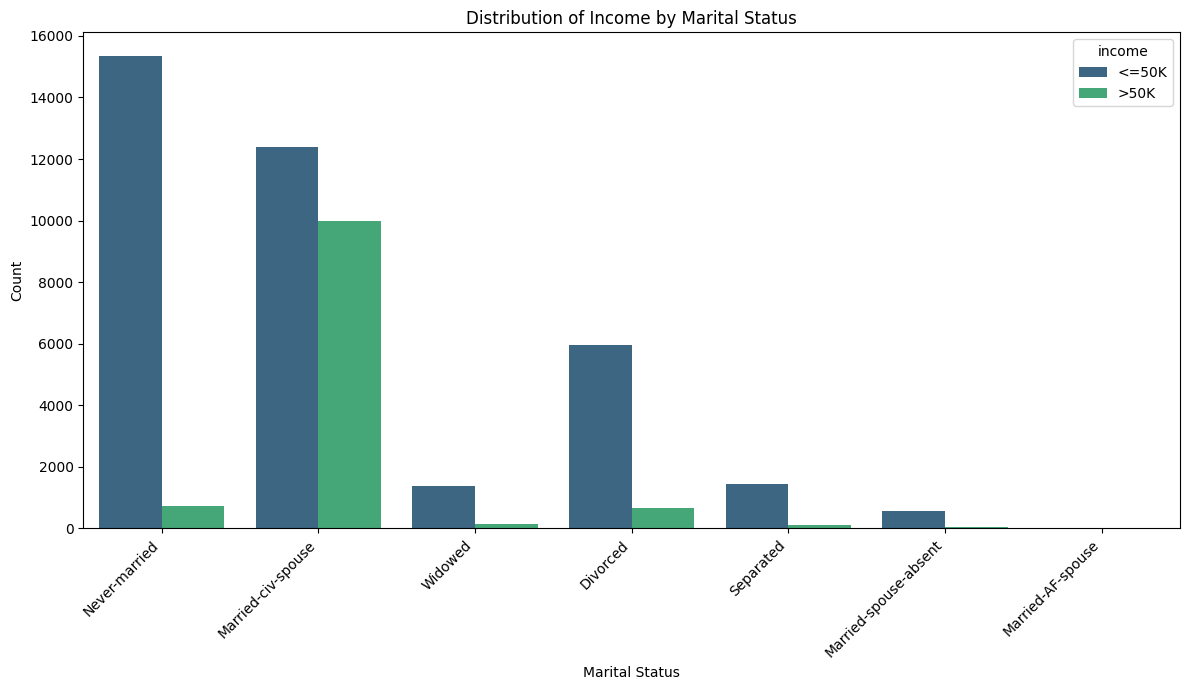

In [ ]:
#Marital Status vs. Income Visualization
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='marital-status', hue='income', palette='viridis')
plt.title('Distribution of Income by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Explanation of Marital Status vs. Income Visualization

This chart illustrates how income levels vary by marital status, providing key insights for our prediction model.

Insights for Prediction:

* 'Married-civ-spouse': This group shows a significantly higher proportion earning '>50K', meaning the model strongly associates this status with higher income.
* 'Never-married' and 'Divorced': These categories predominantly consist of individuals earning '<=50K', leading the model to predict lower income for them.
* Other categories: Similarly show a majority in the lower income bracket, influencing the model's predictions accordingly.

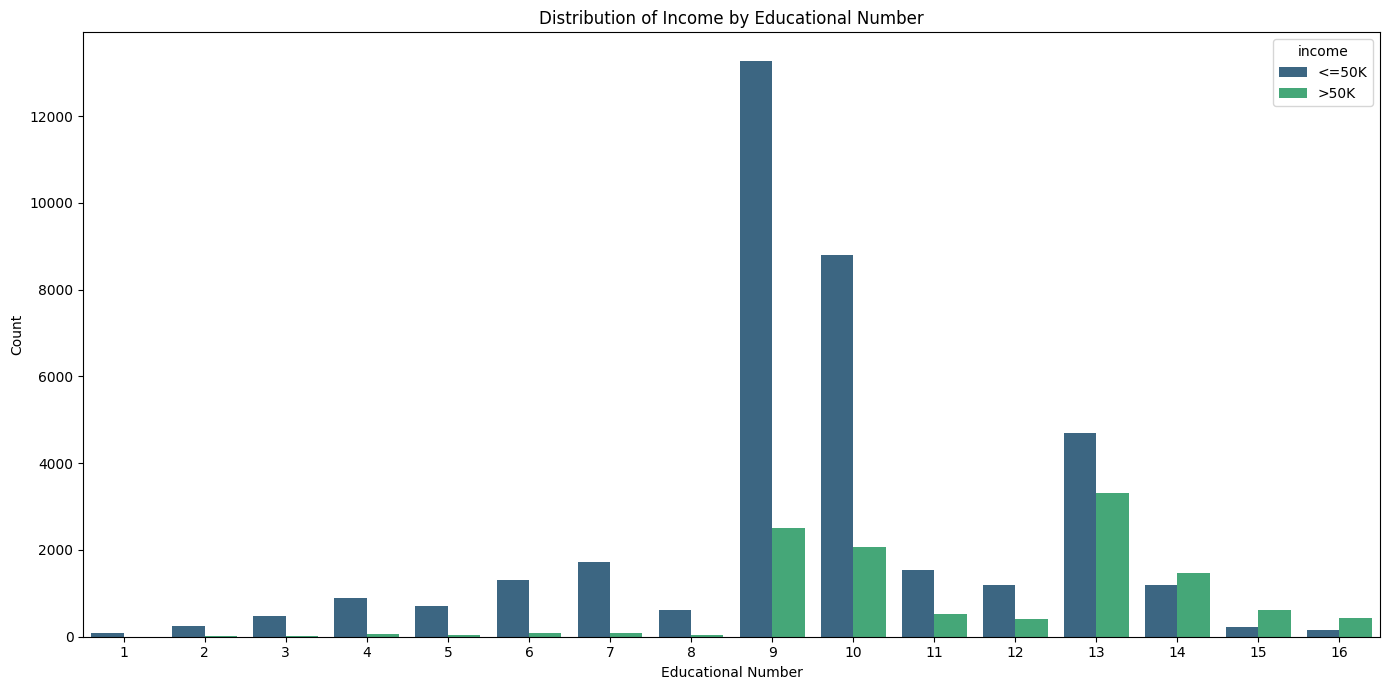

In [ ]:
#Educational Number vs. Income Visualization
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='educational-num', hue='income', palette='viridis')
plt.title('Distribution of Income by Educational Number')
plt.xlabel('Educational Number')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Explanation of Educational Number vs. Income Visualization

Key Insights for Stakeholders:

* Positive Correlation with Income: There is a clear positive correlation between educational attainment (represented by 'Educational Number') and the likelihood of earning '>50K'. As the educational number increases, the proportion of higher-income earners rises significantly.

* Threshold for Higher Income: While lower educational numbers predominantly result in '<=50K' income, a noticeable shift occurs from 'Educational Number' 10 (Some-college) and especially 13 (Bachelors) upwards, where '>50K' earners become more prominent.


#PCA

In [ ]:
# The preprocessor already handles all scaling and encoding for numerical, nominal, and ordinal columns.
# We will use the output of the preprocessor as the fully processed and scaled input.
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("X_train and X_test have been processed and scaled using the defined ColumnTransformer.")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

X_train and X_test have been processed and scaled using the defined ColumnTransformer.
Shape of X_train_scaled: (36592, 93)
Shape of X_test_scaled: (12198, 93)


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
X_train_new = np.hstack((X_train_scaled, X_train_pca))
X_test_new = np.hstack((X_test_scaled, X_test_pca))

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_new,
    y_train
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [ ]:
preds = rf.predict(X_test_new)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27841
        >50K       1.00      1.00      1.00     27841

    accuracy                           1.00     55682
   macro avg       1.00      1.00      1.00     55682
weighted avg       1.00      1.00      1.00     55682



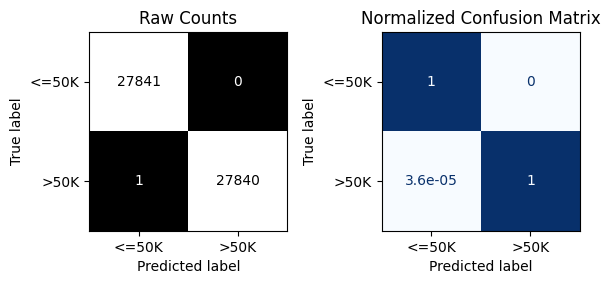


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.91      0.89      0.90      9268
        >50K       0.67      0.71      0.69      2930

    accuracy                           0.85     12198
   macro avg       0.79      0.80      0.79     12198
weighted avg       0.85      0.85      0.85     12198



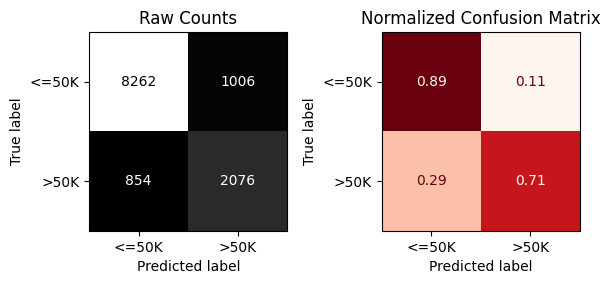

In [ ]:
evaluate_classification(rf, X_train_smote, y_train_smote, X_test_new, y_test)

In [ ]:
importances = rf.feature_importances_

In [ ]:
import numpy as np

indices = np.argsort(importances)[::-1][:10]

In [ ]:
X_train_selected = X_train_smote[:, indices]
X_test_selected = X_test_new[:, indices]

In [ ]:
rf_final = rf.fit(X_train_selected, y_train_smote)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27841
        >50K       1.00      1.00      1.00     27841

    accuracy                           1.00     55682
   macro avg       1.00      1.00      1.00     55682
weighted avg       1.00      1.00      1.00     55682



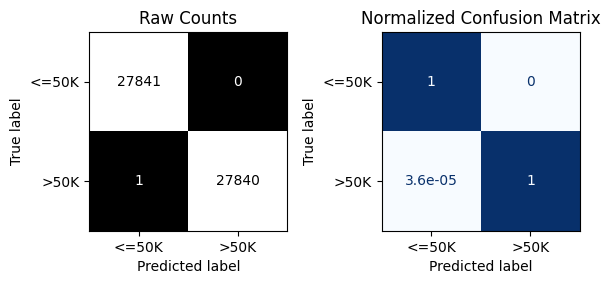


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.91      0.86      0.88      9268
        >50K       0.62      0.73      0.67      2930

    accuracy                           0.83     12198
   macro avg       0.77      0.80      0.78     12198
weighted avg       0.84      0.83      0.83     12198



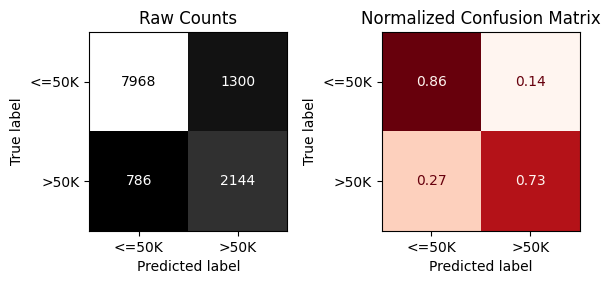

In [ ]:
#evaluate
evaluate_classification(rf_final, X_train_selected, y_train_smote, X_test_selected, y_test)

In [ ]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(
    rf_final,
    X_test_selected,
    y_test,
    n_repeats=10,
    random_state=42
)

In [ ]:
importances = perm.importances_mean
indices = np.argsort(importances)[::-1][:10]

/tmp/ipykernel_5985/1635475218.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=top_10_perm_feature_names_final, palette='viridis')


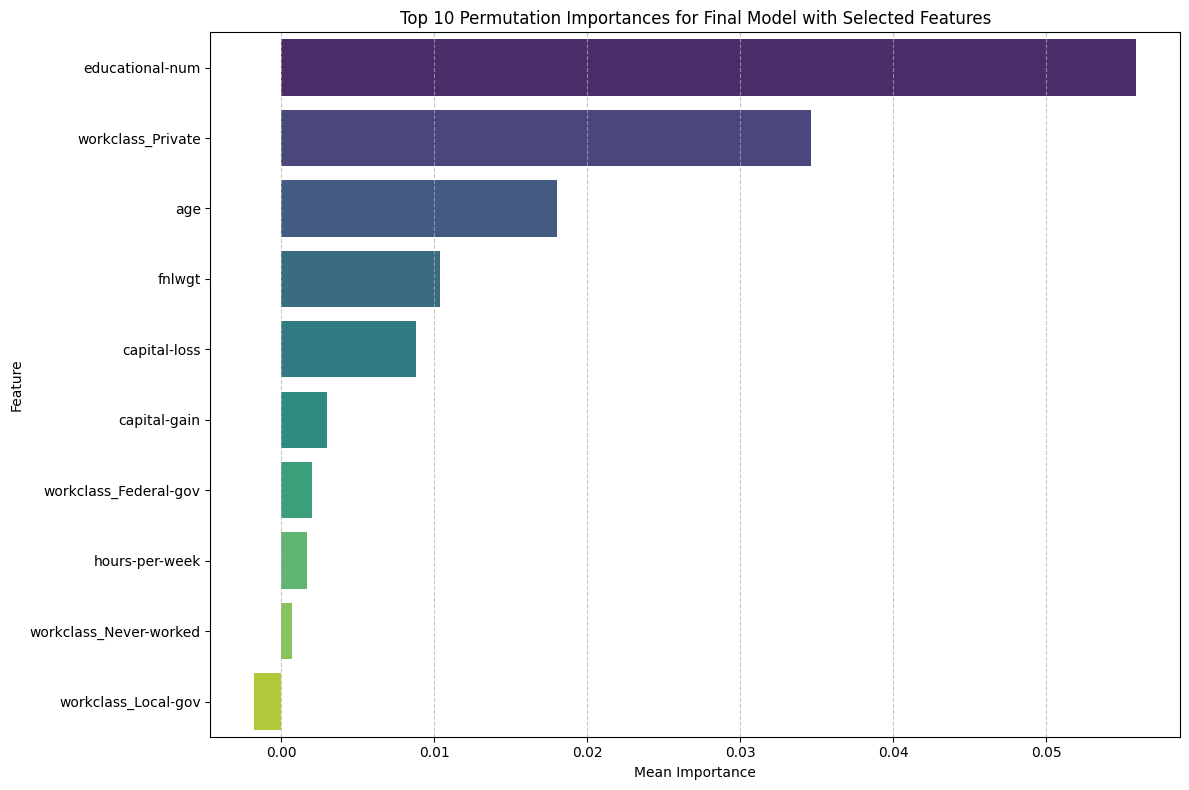

Permutation importance calculated and top 10 features visualized for the final model.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names for the X_train_new (which includes preprocessed original features and PCA components)
# The preprocessor output features and the PCA components have specific indices in X_train_new

# Get feature names from the preprocessor
preprocessor_feature_names = preprocessor.get_feature_names_out()

# Add PCA feature names
pca_feature_names = [f'PCA_{i+1}' for i in range(pca.n_components_)]

# Combine all feature names to match the columns of X_train_new
all_new_feature_names = list(preprocessor_feature_names) + pca_feature_names

# Use the 'indices' from the final permutation importance to get the names of the top features
top_10_perm_feature_names_final = [all_new_feature_names[idx] for idx in indices]

plt.figure(figsize=(12, 8)) # Use the requested figure size

# Plotting the top 10 permutation importances with actual feature names using seaborn
sns.barplot(x=importances[indices], y=top_10_perm_feature_names_final, palette='viridis')

plt.title('Top 10 Permutation Importances for Final Model with Selected Features')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Permutation importance calculated and top 10 features visualized for the final model.")

## Summary: Model Comparison

### Performance Metrics

| Model                               | Training Accuracy | Training Macro Avg F1-score | Test Accuracy | Test Macro Avg F1-score |
| :---------------------------------- | :---------------- | :-------------------------- | :------------ | :---------------------- |
| **Original Random Forest**          | 1.00              | 1.00                        | 0.86          | 0.85                    |
| **Random Forest with PCA**          | 1.00              | 1.00                        | 0.85          | 0.85                    |
| **Random Forest with Selected Features** | 1.00              | 1.00                        | 0.83          | 0.83                    |

### Key Observations:

*   **Overfitting Remains:** All models still exhibit significant overfitting, with perfect scores on the training data but lower performance on the test data. This indicates that the models are memorizing the training data rather than learning generalizable patterns.
*   **Impact of PCA:** Introducing PCA components (`Random Forest with PCA`) resulted in a slight decrease in test accuracy (from 0.86 to 0.85) and maintained the F1-score at 0.85, suggesting PCA did not significantly improve generalization and might have slightly reduced it.
*   **Impact of Feature Selection:** Selecting features (`Random Forest with Selected Features`) based on permutation importance further decreased test accuracy to 0.83 and F1-score to 0.83. This could imply that removing certain features, even if deemed less important, might have led to a loss of valuable information for the model.

### Insights and Next Steps:

1.  **Address Overfitting:** The primary issue across all models is overfitting. Strategies to address this include:
    *   **Hyperparameter Tuning:** Systematically tune hyperparameters of the Random Forest Classifier (e.g., `max_depth`, `min_samples_split`, `min_samples_leaf`, `n_estimators`).
    *   **Regularization:** While Random Forest inherently has some regularization, other models might benefit more explicitly from it.
    *   **Cross-Validation:** Implement cross-validation during training to get a more robust estimate of model performance and aid in hyperparameter tuning.
2.  **Re-evaluate Feature Engineering:** The current feature selection and PCA approaches did not yield better test performance. It's crucial to reconsider these steps:
    *   **Alternative Feature Selection Methods:** Explore other feature selection techniques that might retain more predictive power.
    *   **PCA Components Analysis:** Investigate the variance explained by each PCA component to ensure enough information is captured.
3.  **Explore Other Models:** Given the consistent overfitting with Random Forest, it might be beneficial to explore other classification algorithms that are less prone to overfitting or handle it differently (e.g., Logistic Regression with strong regularization, Gradient Boosting Machines).
4.  **Data Augmentation/More Data:** If possible, obtaining more diverse training data could help reduce overfitting.

Keras

In [ ]:
input_shape = X_train_new.shape[1]
input_shape

96

In [ ]:
def build_model():
    # Instantiate Model
    model = Sequential()

    # First hidden layer
    model.add(Dense(10, # How many neurons you have in your first hidden layer
                input_dim =input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
    model.add(Dense(10,
                activation = 'relu'))
    model.add(Dropout(.2))
    model.add(Dense(1, activation = 'sigmoid'))

    # Compile Model
    model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy', metrics.Precision(), metrics.Recall()])
    return model

In [ ]:
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(input_shape,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', metrics.Precision(), metrics.Recall()])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,273 (24.50 KB)

 Trainable params: 6,273 (24.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train_new)
X_test_s = scaler.transform(X_test_new)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

early_stop = EarlyStopping(monitor='val_loss', patience=10)

# Encode target labels to numerical format (0 and 1)
# y_train_smote is a Series with object dtype (e.g., '<=50K', '>50K')
# y_test is also a Series with object dtype
le = LabelEncoder()
y_train_smote_encoded = le.fit_transform(y_train_smote)
y_test_encoded = le.transform(y_test) # Transform y_test using the same encoder fitted on y_train_smote

history = model.fit(X_train_s, y_train_smote_encoded,
                    validation_split=.2, epochs=50,
                    verbose=1, callbacks=[early_stop])
print("Model training complete.")

Epoch 1/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8202 - loss: 0.3798 - precision_1: 0.6533 - recall_1: 0.4962 - val_accuracy: 0.8544 - val_loss: 0.3082 - val_precision_1: 0.7240 - val_recall_1: 0.6174
Epoch 2/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8540 - loss: 0.3183 - precision_1: 0.7367 - recall_1: 0.6099 - val_accuracy: 0.8564 - val_loss: 0.3044 - val_precision_1: 0.7340 - val_recall_1: 0.6128
Epoch 3/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8599 - loss: 0.3048 - precision_1: 0.7444 - recall_1: 0.6204 - val_accuracy: 0.8583 - val_loss: 0.3007 - val_precision_1: 0.7278 - val_recall_1: 0.6371
Epoch 4/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8562 - loss: 0.3064 - precision_1: 0.7382 - recall_1: 0.6250 - val_accuracy: 0.8552 - val_loss: 0.3008 - val_precision_1: 0.7282 - val_recall_1: 0.6151
Epoch 5/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8592 - loss: 0.3033 - precision_1: 0.7423 - recall_1: 0.6227 -

(<Figure size 600x1200 with 4 Axes>,
 array([<Axes: title={'center': 'accuracy'}>,
        <Axes: title={'center': 'loss'}>,
        <Axes: title={'center': 'precision_1'}>,
        <Axes: title={'center': 'recall_1'}>], dtype=object))

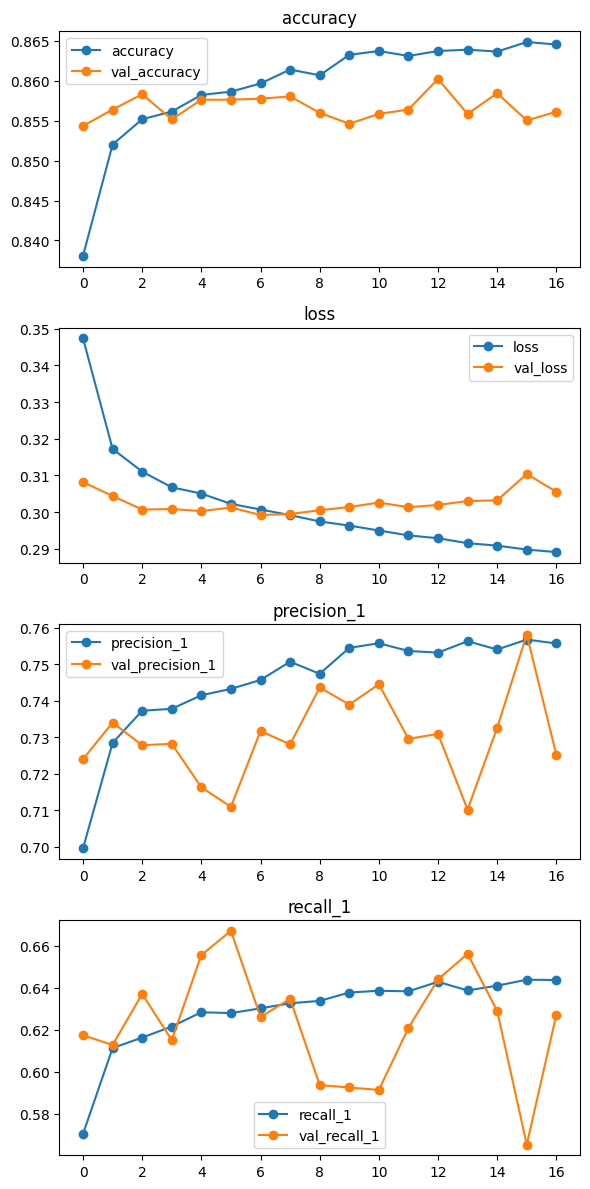

In [ ]:
plot_history(history)

In [ ]:
y_pred_test = model.predict(X_test_s)
y_pred_test[:5]

382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[0.40392974],
       [0.46687287],
       [0.8527786 ],
       [0.7363391 ],
       [0.02911779]], dtype=float32)

In [ ]:
y_pred_test = np.round(y_pred_test)
y_pred_test[:5]

array([[0.],
       [0.],
       [1.],
       [1.],
       [0.]], dtype=float32)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      9268
           1       0.73      0.62      0.67      2930

    accuracy                           0.85     12198
   macro avg       0.81      0.77      0.79     12198
weighted avg       0.85      0.85      0.85     12198



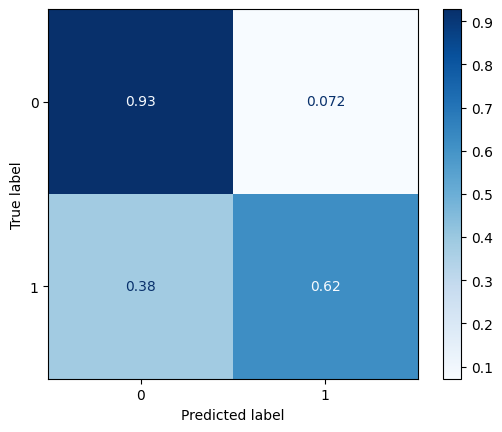

In [ ]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_test_encoded, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test_encoded, y_pred_test, cmap='Blues',
                                       normalize='true');

In [ ]:
model_1 = Sequential()
model_1.add(Input(shape=(input_shape,))) # Ensure input_shape is correctly defined
model_1.add(Dense(128, activation='relu'))
model_1.add(Dense(64, activation='relu'))
model_1.add(Dense(32, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))

model_1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', 'precision', 'recall'])

model_1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,785 (89.00 KB)

 Trainable params: 22,785 (89.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10)

In [ ]:
history1 = model_1.fit(X_train_s, y_train_smote_encoded,
                    validation_split=.2, epochs=50,
                    verbose=1, callbacks=[early_stop])
print("Model training complete.")

Epoch 1/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8275 - loss: 0.3696 - precision: 0.6662 - recall: 0.5032 - val_accuracy: 0.8537 - val_loss: 0.3070 - val_precision: 0.7629 - val_recall: 0.5501
Epoch 2/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8526 - loss: 0.3139 - precision: 0.7418 - recall: 0.5959 - val_accuracy: 0.8580 - val_loss: 0.3095 - val_precision: 0.7018 - val_recall: 0.6916
Epoch 3/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8581 - loss: 0.3042 - precision: 0.7475 - recall: 0.6142 - val_accuracy: 0.8568 - val_loss: 0.3016 - val_precision: 0.7423 - val_recall: 0.6012
Epoch 4/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8551 - loss: 0.3072 - precision: 0.7506 - recall: 0.6026 - val_accuracy: 0.8615 - val_loss: 0.3014 - val_precision: 0.7397 - val_recall: 0.6359
Epoch 5/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8617 - loss: 0.2952 - precision: 0.7564 - recall: 0.6176 - val_accuracy: 0.8579 - val_loss: 0.

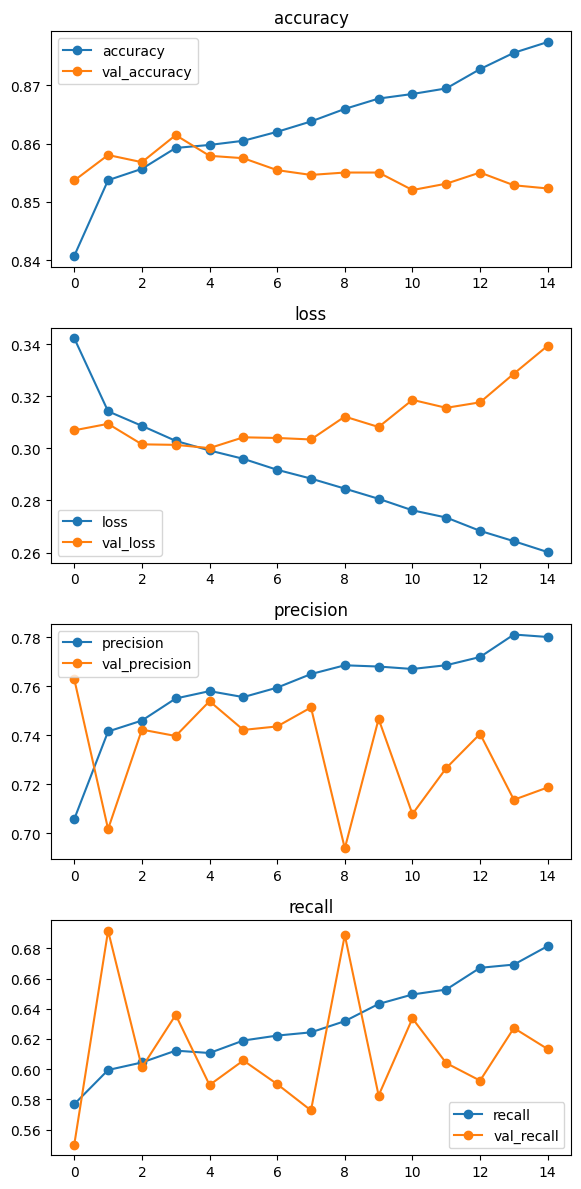

In [ ]:
plot_history(history1);

In [ ]:
y_pred_test = model_1.predict(X_test_new)
y_pred_test[:5]

382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.21892294],
       [0.41288936],
       [0.99135476],
       [0.6443667 ],
       [0.03673228]], dtype=float32)

In [ ]:
y_pred_test = np.round(y_pred_test)
y_pred_test[:5]

array([[0.],
       [0.],
       [1.],
       [1.],
       [0.]], dtype=float32)

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      9268
           1       0.74      0.51      0.61      2930

    accuracy                           0.84     12198
   macro avg       0.80      0.73      0.75     12198
weighted avg       0.83      0.84      0.83     12198



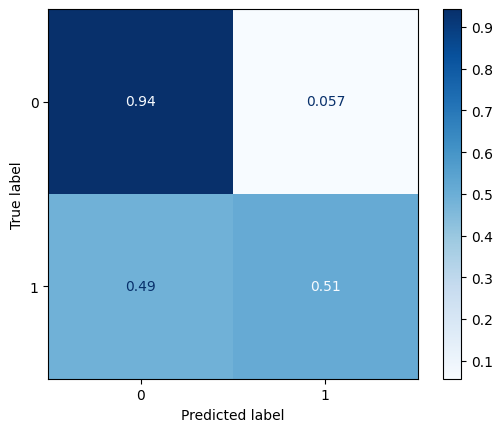

In [ ]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_test_encoded, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test_encoded, y_pred_test, cmap='Blues',
                                       normalize='true');